In [6]:
import pandas as pd
import numpy as np

In [7]:
import numpy as np

# 500 normal data points: tight cluster around the mean
normal_data = np.random.normal(loc=50, scale=10, size=500)

# 25 outliers - extreme high values (like $1M transactions)
outliers = np.random.uniform(low=120, high=200, size=25)

# Combine into one dataset, shuffled
data = np.concatenate([normal_data, outliers])

# print and see the values
np.random.shuffle(data)



In [8]:
import pandas as pd

# Create DataFrame
df = pd.DataFrame({'value': data})

# Display statistics
print(f"Dataset shape: {df.shape}")
print(f"Mean: {df['value'].mean():.2f}")
print(f"Median: {df['value'].median():.2f}")
print(f"Std: {df['value'].std():.2f}")

Dataset shape: (525, 1)
Mean: 56.05
Median: 50.77
Std: 26.49


In [9]:
print(df.head())

        value
0   66.365412
1   57.564872
2  140.605454
3   48.322639
4   52.295173


In [11]:
from scipy import stats

df['z_score'] = stats.zscore(df['value'])
df['is_outlier_z'] = np.abs(df['z_score']) > 3

n_z = df['is_outlier_z'].sum()
print(f"Z-Score falgged {n_z} outliers (threshold |z| > 3)")
print(f"True outliers in dataset: 25") 
print(f"Detection rate: (n_z/ 25:1%)")

Z-Score falgged 22 outliers (threshold |z| > 3)
True outliers in dataset: 25
Detection rate: (n_z/ 25:1%)


In [13]:
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['is_outlier_iqr'] = (df['value'] < lower) | (df['value'] > upper)

print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
print(f"Outlier fences: < {lower:.2f} or > {upper:.2f}")
print(f"IQR flagged {df['is_outlier_iqr'].sum()} outliers")

Q1 = 44.25, Q3 = 58.32, IQR = 14.08
Outlier fences: < 23.13 or > 79.44
IQR flagged 26 outliers


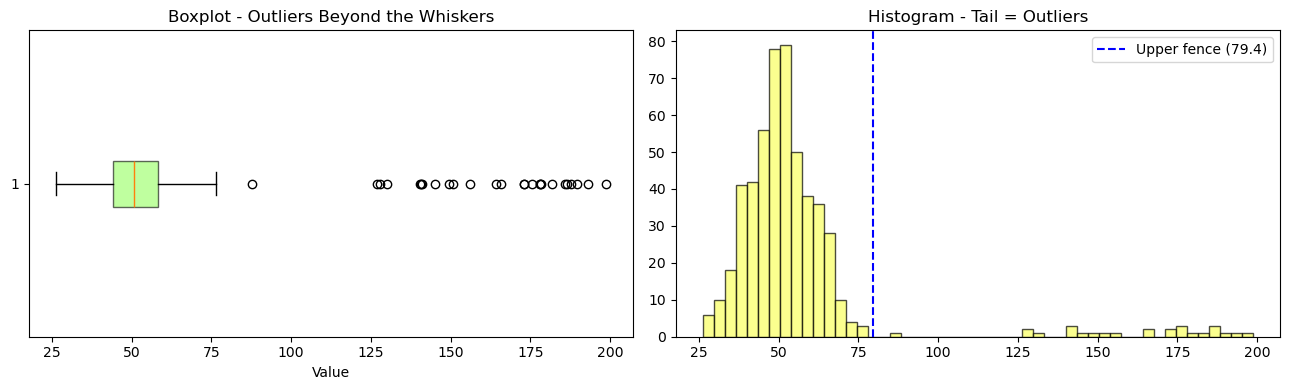

In [18]:
# Visualize
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Boxplot
axes[0].boxplot(df['value'], vert=False, patch_artist=True,
                boxprops=dict(facecolor="#95ff60", alpha=0.6))
axes[0].set_title('Boxplot - Outliers Beyond the Whiskers')
axes[0].set_xlabel('Value')

# Histogram
axes[1].hist(df['value'], bins=50, color="#faff60", edgecolor='black', alpha=0.7)
axes[1].axvline(upper, color='blue', linestyle='--', label=f'Upper fence ({upper:.1f})')
axes[1].set_title('Histogram - Tail = Outliers')
axes[1].legend()

plt.tight_layout()
plt.show()